Customer Churn Prediction using Decision Tree

*   Dataset : Telco Customer Churn (Kaggle)
*   Tools   : Python, Pandas, Scikit-learn, Matplotlib



   CUSTOMER CHURN PREDICTION - Decision Tree Model

📊 Dataset Shape: (7043, 21)

📋 First 5 Rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic       

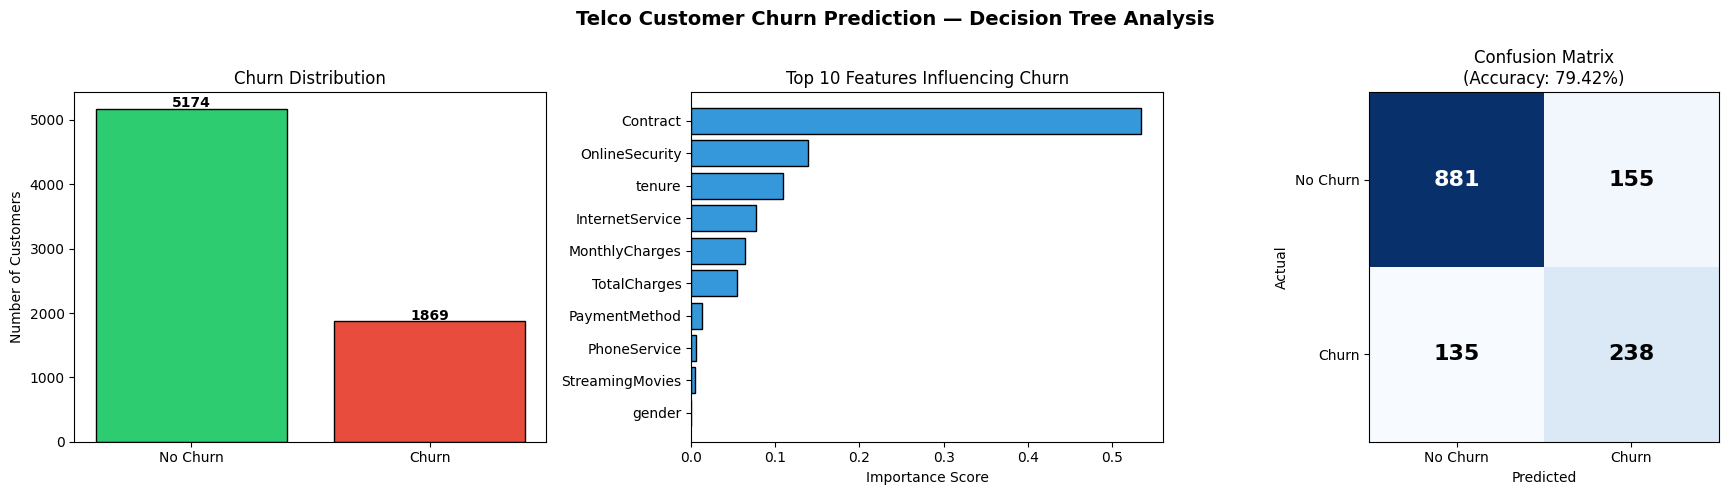


✅ Visualization saved as 'churn_analysis.png'

         PREDICT FOR A NEW CUSTOMER

👤 Customer Profile:
   Tenure         : 2 months
   Contract       : Month-to-month
   Monthly Charges: $85  |  No Online Security

🔮 Prediction       : ⚠️  WILL CHURN
📊 Churn Probability: 67.6%

✅ Project Complete! Check 'churn_analysis.png' for visuals.


In [26]:


# --- STEP 1: Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report)
from sklearn.preprocessing import LabelEncoder

# --- STEP 2: Load Dataset ---
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("=" * 60)
print("   CUSTOMER CHURN PREDICTION - Decision Tree Model")
print("=" * 60)

# --- STEP 3: Exploratory Data Analysis ---
print("\n📊 Dataset Shape:", df.shape)
print("\n📋 First 5 Rows:")
print(df.head())
print("\n📈 Churn Distribution:")
print(df['Churn'].value_counts())
print(f"\n   Churn Rate: {round(df['Churn'].value_counts(normalize=True)['Yes']*100, 2)}%")

# --- STEP 4: Data Cleaning ---

# Drop customerID — not useful for prediction
df.drop('customerID', axis=1, inplace=True)

# TotalCharges has spaces — convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print("\n🔍 Missing Values After Cleaning:", df.isnull().sum().sum())

# --- STEP 5: Encode Categorical Columns ---

# Convert target: Yes=1, No=0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Encode all categorical columns using LabelEncoder
le = LabelEncoder()
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("\n✅ Encoding Complete. All columns are now numeric.")
print("\n📋 Processed Dataset Shape:", df.shape)

# --- STEP 6: Define Features & Target ---
X = df.drop('Churn', axis=1)
y = df['Churn']

# --- STEP 7: Train-Test Split (80% Train / 20% Test) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\n✅ Training Samples : {X_train.shape[0]}")
print(f"✅ Testing Samples  : {X_test.shape[0]}")

# --- STEP 8: Build Decision Tree Model ---
model = DecisionTreeClassifier(
    max_depth=5,       # Keeps tree simple and explainable
    random_state=42
)
model.fit(X_train, y_train)
print("\n✅ Model Training Complete!")

# --- STEP 9: Predictions & Evaluation ---
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n" + "=" * 60)
print("               MODEL EVALUATION RESULTS")
print("=" * 60)
print(f"\n🎯 Accuracy Score : {round(accuracy * 100, 2)}%")
print("\n📊 Confusion Matrix:")
print(cm)
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred,
                            target_names=['No Churn', 'Churn']))

# --- STEP 10: Feature Importance ---
feature_importance = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("🔑 Top 5 Features Influencing Churn:")
print(feature_importance.head().to_string(index=False))

# --- STEP 11: Visualizations ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Telco Customer Churn Prediction — Decision Tree Analysis',
             fontsize=14, fontweight='bold')

# Plot 1: Churn Distribution
churn_counts = df['Churn'].value_counts().sort_index().values
axes[0].bar(['No Churn', 'Churn'], churn_counts,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Churn Distribution')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Plot 2: Top 10 Feature Importance
top_features = feature_importance.head(10)
axes[1].barh(top_features['Feature'], top_features['Importance'],
             color='#3498db', edgecolor='black')
axes[1].set_title('Top 10 Features Influencing Churn')
axes[1].set_xlabel('Importance Score')
axes[1].invert_yaxis()

# Plot 3: Confusion Matrix Heatmap
axes[2].imshow(cm, interpolation='nearest', cmap='Blues')
axes[2].set_title(f'Confusion Matrix\n(Accuracy: {round(accuracy*100, 2)}%)')
axes[2].set_xticks([0, 1])
axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(['No Churn', 'Churn'])
axes[2].set_yticklabels(['No Churn', 'Churn'])
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, str(cm[i, j]),
                     ha='center', va='center', fontsize=16,
                     fontweight='bold',
                     color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.savefig('churn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Visualization saved as 'churn_analysis.png'")

# --- STEP 12: Predict for a New Customer ---
print("\n" + "=" * 60)
print("         PREDICT FOR A NEW CUSTOMER")
print("=" * 60)

# High-risk customer profile:
# New customer, month-to-month contract, high charges, no security
new_customer = pd.DataFrame([{
    'gender'          : 1,       # Male
    'SeniorCitizen'   : 0,
    'Partner'         : 0,       # No partner
    'Dependents'      : 0,
    'tenure'          : 2,       # Only 2 months old
    'PhoneService'    : 1,
    'MultipleLines'   : 0,
    'InternetService' : 1,
    'OnlineSecurity'  : 0,       # No security — risk factor
    'OnlineBackup'    : 0,
    'DeviceProtection': 0,
    'TechSupport'     : 0,
    'StreamingTV'     : 0,
    'StreamingMovies' : 0,
    'Contract'        : 0,       # Month-to-month — highest churn risk
    'PaperlessBilling': 1,
    'PaymentMethod'   : 2,
    'MonthlyCharges'  : 85.0,    # High monthly charges
    'TotalCharges'    : 170.0
}])

prediction  = model.predict(new_customer)
probability = model.predict_proba(new_customer)

print(f"\n👤 Customer Profile:")
print(f"   Tenure         : 2 months")
print(f"   Contract       : Month-to-month")
print(f"   Monthly Charges: $85  |  No Online Security")
print(f"\n🔮 Prediction       : {'⚠️  WILL CHURN' if prediction[0]==1 else '✅  WILL NOT CHURN'}")
print(f"📊 Churn Probability: {round(probability[0][1]*100, 2)}%")
print(f"\n✅ Project Complete! Check 'churn_analysis.png' for visuals.")